# Elliptic Dataset

## Overview

From kaggle, we have the following description: 

The Elliptic Data Set maps Bitcoin transactions to real entities belonging to licit categories (exchanges, wallet providers, miners, licit services, etc.) versus illicit ones (scams, malware, terrorist organizations, ransomware, Ponzi schemes, etc.). The task on the dataset is to classify the illicit and licit nodes in the graph.

**Nodes and edges**

The graph is made of 203,769 nodes and 234,355 edges. Two percent (4,545) of the nodes are labelled class1 (illicit). Twenty-one percent (42,019) are labelled class2 (licit). The remaining transactions are not labelled with regard to licit versus illicit.

**Features**

There are 166 features associated with each node. Due to intellectual property issues, we cannot provide an exact description of all the features in the dataset. There is a time step associated to each node, representing a measure of the time when a transaction was broadcasted to the Bitcoin network. The time steps, running from 1 to 49, are evenly spaced with an interval of about two weeks. Each time step contains a single connected component of transactions that appeared on the blockchain within less than three hours between each other; there are no edges connecting the different time steps.

The first 94 features represent local information about the transaction – including the time step described above, number of inputs/outputs, transaction fee, output volume and aggregated figures such as average BTC received (spent) by the inputs/outputs and average number of incoming (outgoing) transactions associated with the inputs/outputs. The remaining 72 features are aggregated features, obtained using transaction information one-hop backward/forward from the center node - giving the maximum, minimum, standard deviation and correlation coefficients of the neighbour transactions for the same information data (number of inputs/outputs, transaction fee, etc.).

## Approach

We are going to tackle this problem applying a scalable distributed solution with Apache Spark. The things we need to note from the description is that this is a semi-supervised problem in a transductive setting, with data whose topology is a graph. We will make the pertinent hypothesis after the data analysis.

## Exploratory Data Analysis

In [1]:
import kagglehub, os


os.makedirs("data", exist_ok=True)

path = kagglehub.dataset_download("ellipticco/elliptic-data-set")
print("Path to dataset files:", path)

/home/administrador/.pyenv/versions/elliptic/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 146M/146M [00:08<00:00, 17.2MB/s] 

Extracting files...


Path to dataset files: /home/administrador/.cache/kagglehub/datasets/ellipticco/elliptic-data-set/versions/1


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Elliptic Dataset") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

sc = spark.sparkContext

JAVA_HOME is not set


PySparkRuntimeError: [JAVA_GATEWAY_EXITED] Java gateway process exited before sending its port number.

In [ ]:
import pandas as pd


df_classes = pd.read_csv(
  path + "/elliptic_bitcoin_dataset/elliptic_txs_classes.csv"
)
df_classes = spark.createDataFrame(df_classes)

df_edges = pd.read_csv(
  path + "/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv"
)
df_edges = spark.createDataFrame(df_edges)

df_features = pd.read_csv(
  path + "/elliptic_bitcoin_dataset/elliptic_txs_features.csv",
  header=None
)
df_features = spark.createDataFrame(df_features)

/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:416: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:416: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-pa

In [ ]:
df_classes.show(5)

+---------+-------+
|     txId|  class|
+---------+-------+
|230425980|unknown|
|  5530458|unknown|
|232022460|unknown|
|232438397|      2|
|230460314|unknown|
+---------+-------+
only showing top 5 rows


Traceback (most recent call last):                                  (0 + 1) / 1]
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


In [ ]:
df_edges.show(5)

+---------+---------+
|    txId1|    txId2|
+---------+---------+
|230425980|  5530458|
|232022460|232438397|
|230460314|230459870|
|230333930|230595899|
|232013274|232029206|
+---------+---------+
only showing top 5 rows


In [ ]:
df_features.show(5)

Traceback (most recent call last):
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe
26/04/13 19:07:32 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/04/13 19:07:32 WARN TaskSetManager: Stage 2 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


+---------+---+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+---------

Traceback (most recent call last):
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


In [ ]:
df_features = df_features.withColumnRenamed("0", "txId")
df_features.show(5)

+---------+---+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+---------

26/04/13 19:07:32 WARN TaskSetManager: Stage 3 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.
Traceback (most recent call last):
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


As we can see, the majority of features do not really have a lot of semantic meaning. But, from kaggle, we know that there is another important feature, which is the timestamp. The column '1' seems suspecting, we will check it.

In [ ]:
df_features.describe("1").show()

26/04/13 19:07:33 WARN TaskSetManager: Stage 4 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


+-------+------------------+
|summary|                 1|
+-------+------------------+
|  count|            203769|
|   mean|23.843960563186744|
| stddev|15.172170045043556|
|    min|                 1|
|    max|                49|
+-------+------------------+



It matches with the kaggle text, so we rename the column.

In [ ]:
df_features = df_features.withColumnRenamed("1", "timestamp")
df_features.show(5)

26/04/13 19:07:35 WARN TaskSetManager: Stage 7 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.
Traceback (most recent call last):
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


+---------+---------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+---

It is always good practice to check the possible null values.

In [ ]:
from pyspark.sql.functions import col, count, when, isnan


df_null = df_features.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in df_features.columns
])

df_null.show()

26/04/13 19:07:36 WARN TaskSetManager: Stage 8 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


+----+---------+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+
|txId|timestamp|  2|  3|  4|  5|  6|  7|  8|  9| 10| 11| 12| 13| 14| 15| 16| 17| 18| 19| 20| 21| 22| 23| 24| 25| 26| 27| 28| 29| 30| 31| 32| 33| 34| 35| 36| 37| 38| 39| 40| 41| 42| 43| 44| 45| 46| 47| 48| 49| 50| 51| 52| 53| 54| 55| 56| 57| 58| 59| 60| 61| 62| 63| 64| 65| 66| 67| 68| 69| 70| 71| 72| 73| 74| 75| 76| 77| 78

We will check now the classes to see how they are distributed, since the description in kaggle seems to point to a severe case of class imbalance.

/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


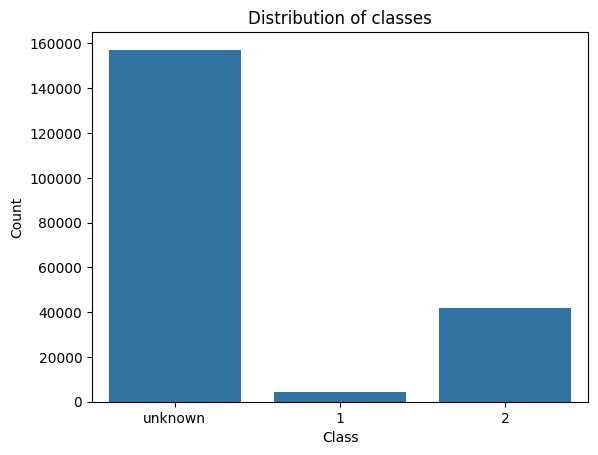

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


df_count = df_classes.groupBy("class").count().toPandas()

sns.barplot(x="class", y="count", data=df_count)
plt.title("Distribution of classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Since we want to implement a distributed solution, we will need a heuristic to determine the partitions for feeding our ML models. Letting Spark decide is not necessarily wrong, but our data is structured in a graph. This means that there are potential implications in implementing a distributed ML solution with partitions that do not take into account the structure of the graph.

The timestamp column is particularly relevant. If we recall from the description, "Each time step contains a single connected component of transactions that appeared on the blockchain within less than three hours between each other; there are no edges connecting the different time steps.". Thus, a partition based on this column is a very natural choice. Nevertheless, we will try to check if this holds true.

In [ ]:
f1 = df_features.alias("f1")
f2 = df_features.alias("f2")

df_joined = df_edges \
    .join(f1, col("txId1") == col("f1.txId"), "inner") \
    .join(f2, col("txId2") == col("f2.txId"), "inner")

df_final = df_joined.select(
    col("f1.timestamp").alias("timestamp_1"),
    col("f2.timestamp").alias("timestamp_2")
)

df_final.show(5)

print(f"Number of rows of the joined dataframe: {df_final.count()}")

distinct_count = df_final.filter(col("timestamp_1") != col("timestamp_2")).count()
print(f"Number of edges where the timestamps are different for each node: {distinct_count}")

26/04/13 19:32:00 WARN TaskSetManager: Stage 87 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.
26/04/13 19:32:02 WARN TaskSetManager: Stage 93 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


+-----------+-----------+
|timestamp_1|timestamp_2|
+-----------+-----------+
|          1|          1|
|          1|          1|
|          1|          1|
|          1|          1|
|          1|          1|
+-----------+-----------+
only showing top 5 rows


26/04/13 19:32:04 WARN TaskSetManager: Stage 102 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


Number of rows of the final dataframe: 234355


Number of rows of the rows where timestamps are different for each node: 0


Now, since we could potentially make use of this fact, it is convenient to explore class distribution grouped by timestamps:

In [ ]:
df_dist = df_features.join(df_classes, col("txId") == col("df_features.txId"), "inner")
df_dist = df_dist.groupBy([col("timestamp"), col("class")]).count()

df_dist.show()

## Model Training

The nature of the graph as disjoint connected components seems that it should play a role in the design of the model architecture and training technique. In particular, bagging comes to mind as a natural approach to train on subsets of a dataset and aggregate the result.

On the other hand, we are not able to train just with tabular algorithms, since we also desire to take advantage of the topology of the graph itself. A very natural approach is to use GNNs, since they are able to aggregate both topology and node (and potentially edge) features, in a way that a transductive problem can be solved effectively. The question that arises is wether a bagging approach using small networks makes sense in comparison with a global approach.

### GNNs overview

There are several types of GNNs, but we will focus on Graph Convolutional Networks (GCNs). These models are convolutional in the sense that update each node by aggregating information from nearby nodes, and as such, they induce a relational inductive bias [1]. Each layer of the GCN can be described as a function $F[\bullet]$ with parameters $\Phi$ that takes the node embeddings and adjacency matrix and outputs new node embeddings:

$$H_1 = F[X, A, \Phi_0]$$
$$H_2 = F[H_1, A, \Phi_1]$$
$$\vdots$$
$$H_K = F[H_{K-1}, A, \Phi_{K-1}]$$

where $X$ is the input, $A$ the adjacency matrix, $H_k$ contains the modified node embeddings at the $k$-th layer, and $\Phi_k$ are the parameters associated with that layer. At the level of a single node, we have:

$$h_{k+1}^{(n)} = a[\beta_k + \Omega_k \cdot h_{k}^{(n)} + \Omega_k \cdot agg[n,k]]$$

where $a[\bullet]$ is the activation function, $\Omega_k$ is some linear transformation and $agg[\bullet]$ is an aggregation function on the neighborhood of the node, which could be just the sum of the neighbour embeddings. At the level of a whole layer, this can be written as:

$$H_{k+1} = a[\beta_k 1^T + \Omega_k H_{k} + \Omega_k H_k A] = a[\beta_k 1^T + \Omega_k H_{k} (A + I)]$$

In a more informal way, a GCN enriches the input embeddings of the graph nodes with information of their surroundings, outputting an enriched embedding for each node. This makes a GCN particularly suitable for transductive settings. In particular, for our purposes of node binary classification, the final layer should be of the following form:

$$f[X, A, \Phi] = sig[\beta_K 1^T + w_K H_K]$$

where $sig[\bullet]$ is a sigmoid function that gets applied independently to every element of the row vector input. In other words, we will have a predicted label $y^{(n)}$ for each node $n$ of the graph. The loss will then be a usual binary cross entropy, but with a couple of caveats:

- It will only be applied to the nodes for which we have a ground truth, meaning we will need to apply a mask. This shows why a GNN is so suitable for our purposes: the unlabeled nodes will simply be classified like any other node.
- Our classes are severely unbalanced. We can apply here other strategies, but the most simple one is modifying the loss function. We will try to apply focal loss [2].

The binary cross entropy loss function can be written as:

$$l(y, \hat{y}) = - (1 - y) \log(1 - \hat{y}) - y \log(\hat{y})$$

where $y \in \{1, -1\}$ is the ground truth label and $\hat{y} \in [0, 1]$ is the probability predicted for the model.